# What Drives the Price of a Car?

![](images/kurt.jpeg)

**Practical Application II — CRISP-DM analysis of a used-car dataset**

Audience: a used-car dealership looking to fine-tune inventory.


## CRISP-DM Framework

<center><img src="images/crisp.png" width="50%"></center>

CRISP-DM is the industry standard for data projects. The six phases — Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, and Deployment — give us a repeatable structure that keeps the business question front and center. The phases are iterative: findings in later phases often send us back to earlier ones (for example, modeling residuals revealing data-quality issues we missed).


## 1. Business Understanding

**Business question:** A used-car dealership wants to know what makes a car more or less expensive so they can stock inventory that consumers value.

**Reframed as a data problem:**

> Build a supervised regression model that predicts the listed sale price of a used vehicle from its observable attributes (age, mileage, manufacturer, body type, condition, drivetrain, fuel type, title status, geographic market, etc.). Use the trained model's coefficients / feature importances to identify which attributes have the largest positive or negative effect on price, controlling for the others. Success means (a) a model whose held-out error is meaningfully smaller than predicting the mean, and (b) feature-level insights stable enough to act on when buying inventory.

Key choices implied by that framing:

- **Target:** `price` (continuous → regression).
- **Evaluation:** RMSE and MAE in dollars (interpretable to the dealer); R² to compare models.
- **Validation:** train/test split plus k-fold cross-validation to make sure findings are not specific to one split.
- **Deliverable:** ranked list of price drivers with dollar-magnitude impact, not just a black-box model.


## 2. Data Understanding

Steps for getting to know the dataset:

1. Load and check shape, dtypes, and a few sample rows.
2. Quantify missingness column-by-column.
3. Inspect the target (`price`) for outliers and zero values that would distort modeling.
4. Inspect numeric features (`year`, `odometer`) for impossible values.
5. Inspect categorical features for cardinality and frequency of each level.
6. Look at preliminary relationships (price vs. age, odometer, condition, manufacturer, type).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100



In [3]:
df = pd.read_csv('data/vehicles.csv')
print('Shape:', df.shape)


Shape: (426880, 18)


In [4]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [5]:
print('Dtypes and non-null counts:')
df.info()

Dtypes and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  

In [6]:
# Missing values in the Dataset and ration against the total values in Dataframe df
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).head(20)

,missing,pct
size,306361,71.8
cylinders,177678,41.6
condition,174104,40.8
VIN,161042,37.7
drive,130567,30.6
paint_color,130203,30.5
type,92858,21.8
manufacturer,17646,4.1
title_status,8242,1.9
model,5277,1.2


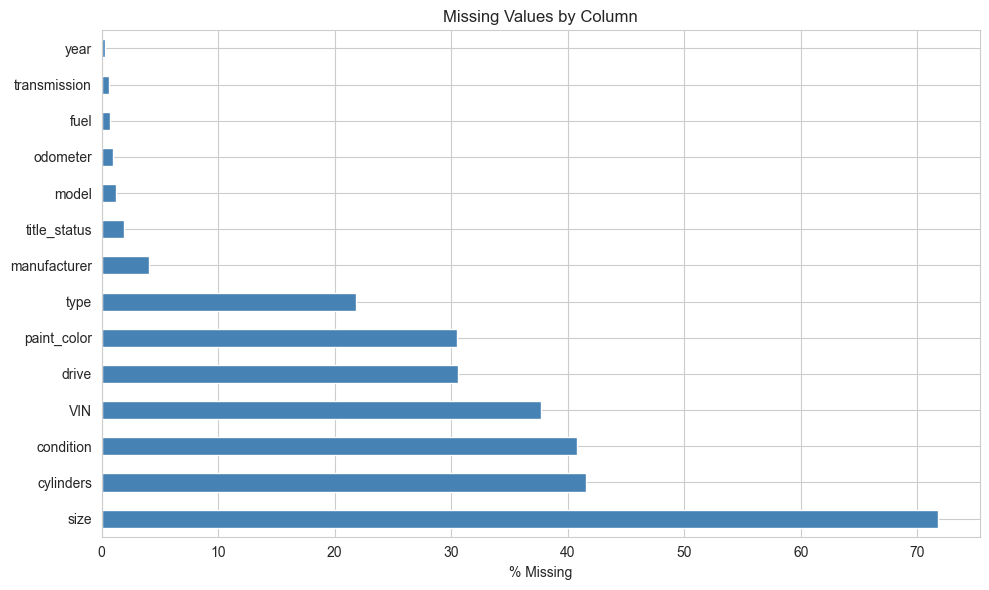

In [7]:
# Visualization of missing values dataset
fig, ax = plt.subplots(figsize=(10, 6))
missing_pct[missing_pct > 0].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% Missing'); ax.set_title('Missing Values by Column')
plt.tight_layout(); plt.show()

In [12]:
# Target inspection
print(df['price'].describe())
print('\nPrice percentiles:')
print(df['price'].quantile([0.01, 0.05, 0.5, 0.75, 0.95, 0.99, 0.999]))
print('\nNumber of $0 prices:', (df['price'] == 0).sum())
print('Number of prices > $200k:', (df['price'] > 200000).sum())

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

Price percentiles:
0.010         0.00
0.050         0.00
0.500     13950.00
0.750     26485.75
0.950     44500.00
0.990     66995.00
0.999    120000.00
Name: price, dtype: float64

Number of $0 prices: 32895
Number of prices > $200k: 124


In [15]:
# Numeric features avaiable in the dataset
print('Year:'); print(df['year'].describe())
print('\nOdometer:')
print(df['odometer'].describe())
print('\nOdometer percentiles:')
print(df['odometer'].quantile([0.01, 0.5, 0.75,0.95, 0.99, 0.999]))

Year:
count    425675.000000
mean       2011.235191
std           9.452120
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

Odometer:
count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64

Odometer percentiles:
0.010          2.0
0.500      85548.0
0.750     133542.5
0.950     204000.0
0.990     280000.0
0.999    1111111.0
Name: odometer, dtype: float64


In [16]:
# Quick look at other categories where null values are limited. This is based on the plot printed above.

for c in ['manufacturer','condition','cylinders','fuel','transmission','drive','type','title_status']:
    print(f'\n{c}:'); print(df[c].value_counts().head(10))


manufacturer:
manufacturer
ford         70985
chevrolet    55064
toyota       34202
honda        21269
nissan       19067
jeep         19014
ram          18342
gmc          16785
bmw          14699
dodge        13707
Name: count, dtype: int64

condition:
condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

cylinders:
cylinders
6 cylinders     94169
4 cylinders     77642
8 cylinders     72062
5 cylinders      1712
10 cylinders     1455
other            1298
3 cylinders       655
12 cylinders      209
Name: count, dtype: int64

fuel:
fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

transmission:
transmission
automatic    336524
other         62682
manual        25118
Name: count, dtype: int64

drive:
drive
4wd    131904
fwd    105517
rwd     58892
Name: count, dtype: int64

type:
type
sedan          87056
SU

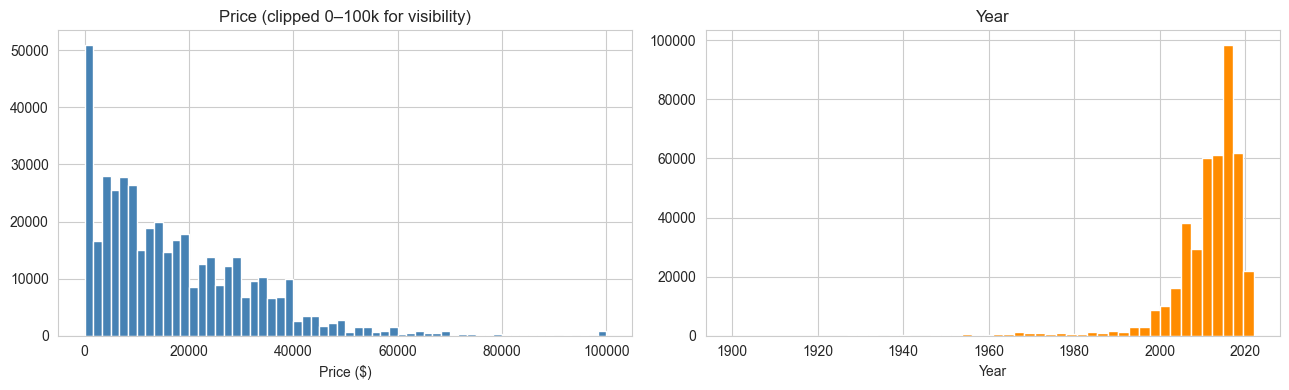

In [17]:
# Visualization of Price and Year (Numerical)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#Price
df['price'].clip(0, 100000).hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Price (clipped 0–100k for visibility)')
axes[0].set_xlabel('Price ($)')

#Year
df['year'].dropna().hist(bins=50, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Year')
axes[1].set_xlabel('Year')

plt.tight_layout(); plt.show()

**Quality issues observed:**

- **Price has extreme outliers.** Maximum price is in the billions; ~33k rows have `price = 0` and ~42k are below $500. These are listing errors / placeholders, not real prices.
- **Heavy missingness in several columns.** `size` is 72% missing, `cylinders` 42%, `condition` 41%, `VIN` 38%, `drive` 31%, `paint_color` 31%, `type` 22%.
- **`model` has extremely high cardinality** (~29k unique values). Useful in principle but unwieldy for linear models and will overfit unless aggressively grouped.
- **`VIN` is a unique-ish identifier** with no generalization value once we have manufacturer/model/year.
- **`region` is high-cardinality (~400 values)** and largely redundant with `state`.
- **Odometer** has values up to 10M miles — impossible — but only at the very top end.
- **`year`** has a long tail of pre-1990 vehicles (collector market follows different pricing rules and isn't representative of a typical dealer's inventory).

## 3. Data Preparation

Based on the quality issues above:

| Decision | Reason |
|---|---|
| Drop `id`, `VIN` | Identifiers, no predictive value |
| Drop `model` | ~29k unique values — would explode the design matrix and overfit; `manufacturer` + `type` + `cylinders` captures most of the brand/body signal |
| Drop `region` | ~400 values; `state` is a cleaner geographic feature |
| Drop `size` | 72% missing — too sparse to impute reliably |
| Filter `price` to [$500, $100,000] | Removes listing-error rows on both ends |
| Filter `year` ≥ 1990 | Excludes collector-car regime |
| Filter `odometer` to [0, 300,000] | Removes obvious data-entry errors |
| Engineer `age = 2022 - year` | More interpretable than raw year |
| Drop rows missing `manufacturer`, `fuel`, `transmission`, `title_status` | Core features; small enough share to drop |
| Fill remaining missing categoricals with `'unknown'` | Lets the model learn a coefficient for "data missing" rather than discarding rows |
| Keep top 25 manufacturers | Long tail of rare brands adds noise |


In [18]:
df_clean = df.drop(columns=['id', 'VIN', 'model', 'region', 'size']).copy()

# Price filter
df_clean = df_clean[(df_clean['price'] >= 500) & (df_clean['price'] <= 100000)]

# Year filter + age engineering
df_clean = df_clean[df_clean['year'].notna()]
df_clean = df_clean[df_clean['year'] >= 1990]

df_clean['age'] = 2022 - df_clean['year']
df_clean = df_clean.drop(columns=['year'])

# Odometer filter
df_clean = df_clean[df_clean['odometer'].notna()]
df_clean = df_clean[(df_clean['odometer'] >= 0) & (df_clean['odometer'] <= 300000)]

# Drop rows missing critical categoricals
df_clean = df_clean.dropna(subset=['manufacturer','fuel','transmission','title_status'])

# Fill remaining categoricals
for col in ['condition','cylinders','drive','type','paint_color']:
    df_clean[col] = df_clean[col].fillna('unknown')

# Keep top 25 manufacturers
top_mfrs = df_clean['manufacturer'].value_counts().head(25).index
df_clean = df_clean[df_clean['manufacturer'].isin(top_mfrs)]

print('Cleaned shape:', df_clean.shape)
df_clean.describe()

Cleaned shape: (330176, 13)


,price,odometer,age
count,330176.000000,330176.000000,330176.000000
mean,19324.796163,93447.426503,9.620396
std,14183.633926,61893.739711,5.738287
min,500.000000,0.000000,0.000000
25%,7995.000000,39508.000000,5.000000
50%,15995.000000,89296.000000,8.000000
75%,27990.000000,137000.000000,13.000000
max,100000.000000,300000.000000,32.000000


In [21]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 330176 entries, 27 to 426879
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         330176 non-null  int64  
 1   manufacturer  330176 non-null  str    
 2   condition     330176 non-null  str    
 3   cylinders     330176 non-null  str    
 4   fuel          330176 non-null  str    
 5   odometer      330176 non-null  float64
 6   title_status  330176 non-null  str    
 7   transmission  330176 non-null  str    
 8   drive         330176 non-null  str    
 9   type          330176 non-null  str    
 10  paint_color   330176 non-null  str    
 11  state         330176 non-null  str    
 12  age           330176 non-null  float64
dtypes: float64(2), int64(1), str(10)
memory usage: 35.3 MB


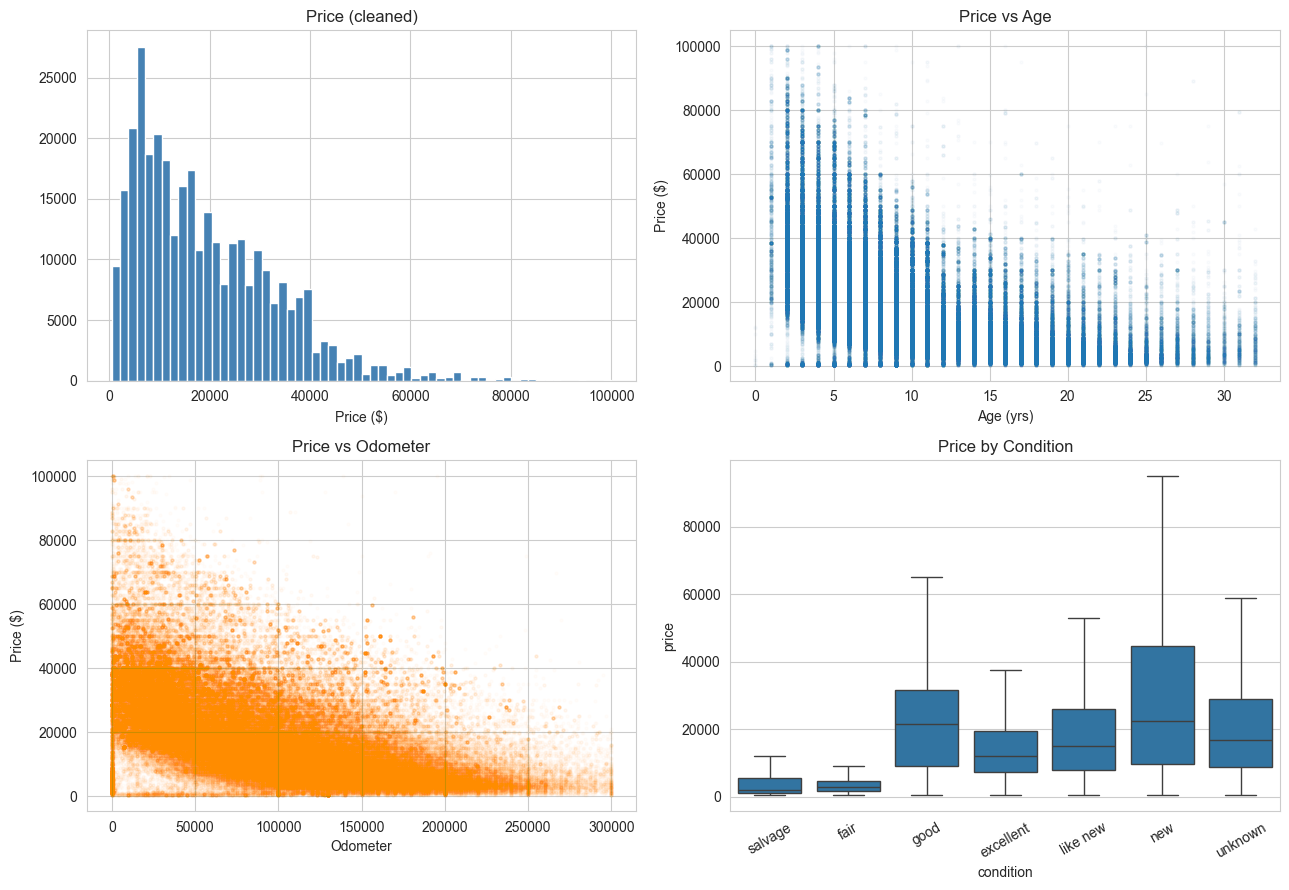

In [26]:
# Cleaned Dataset
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
df_clean['price'].hist(bins=60, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Price (cleaned)'); axes[0,0].set_xlabel('Price ($)')

axes[0,1].scatter(df_clean['age'], df_clean['price'], alpha=0.02, s=4)
axes[0,1].set_title('Price vs Age'); axes[0,1].set_xlabel('Age (yrs)'); axes[0,1].set_ylabel('Price ($)')

axes[1,0].scatter(df_clean['odometer'], df_clean['price'], alpha=0.02, s=4, color='darkorange')
axes[1,0].set_title('Price vs Odometer'); axes[1,0].set_xlabel('Odometer'); axes[1,0].set_ylabel('Price ($)')

cond_order = ['salvage','fair','good','excellent','like new','new','unknown']
cond_avail = [c for c in cond_order if c in df_clean['condition'].unique()]

sns.boxplot(data=df_clean, x='condition', y='price', order=cond_avail, ax=axes[1,1], showfliers=False)

axes[1,1].set_title('Price by Condition'); axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

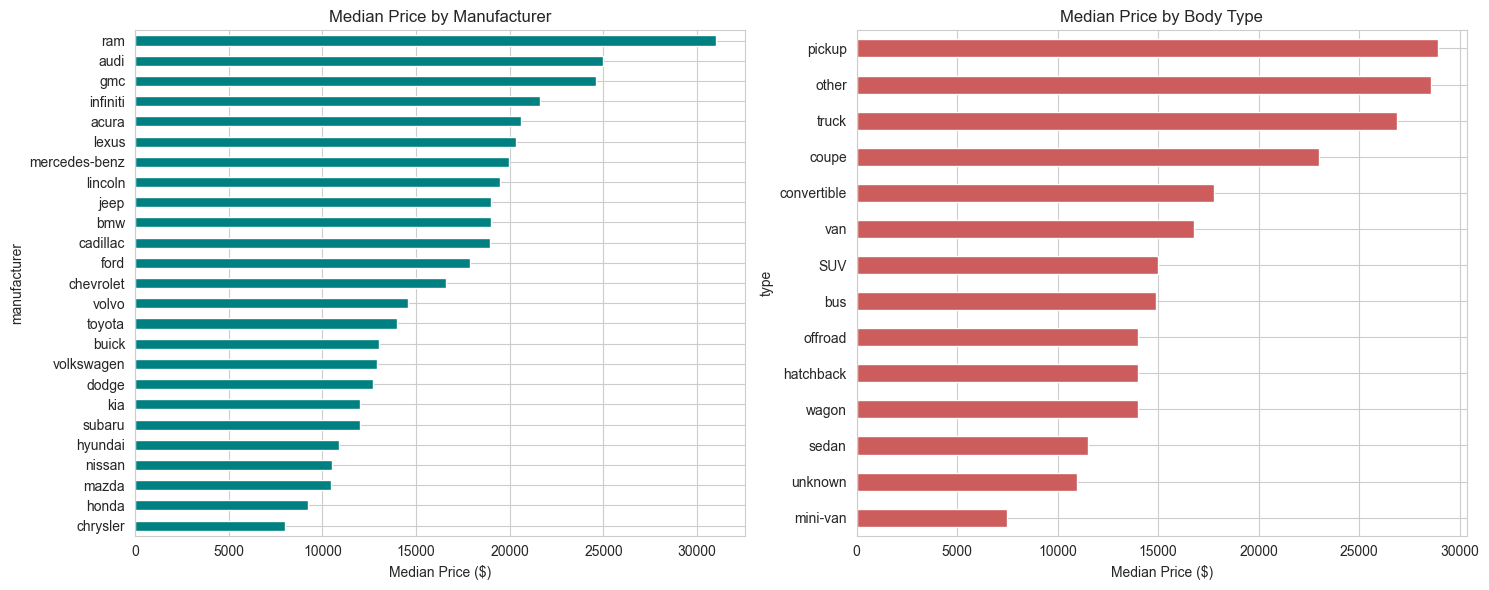

In [27]:
# Median price by manufacturer and by type
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
df_clean.groupby('manufacturer')['price'].median().sort_values().plot(
    kind='barh', ax=axes[0], color='teal')
axes[0].set_xlabel('Median Price ($)'); axes[0].set_title('Median Price by Manufacturer')

df_clean.groupby('type')['price'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='indianred')
axes[1].set_xlabel('Median Price ($)'); axes[1].set_title('Median Price by Body Type')
plt.tight_layout(); plt.show()

**Observations from the cleaned data:**

- Price drops smoothly with both age and odometer — exactly what we'd expect.
- Condition has a clear monotonic effect: `salvage` < `fair` < `good` < `excellent` < `like new` < `new`.
- Luxury brands (Lexus, Mercedes-Benz, BMW, Audi, Ram, GMC) command the highest medians; economy brands (Hyundai, Kia, Nissan, Honda, Volkswagen) the lowest.
- Pickups, trucks, off-road and convertibles command higher prices than sedans and hatchbacks.

## 4. Modeling

We'll fit several regression models on the cleaned data with `price` as the target:

1. **Linear Regression** — baseline, gives interpretable coefficients.
2. **Ridge Regression** (L2) — controls for one-hot multicollinearity; coefficients are our primary interpretation tool.
3. **Lasso Regression** (L1) — gives feature selection by zeroing out unimportant features.
4. **Gradient Boosting** — non-linear benchmark to see how much signal the linear models leave on the table.

Numeric features (`age`, `odometer`) are median-imputed and standard-scaled; categoricals are one-hot encoded. The whole transformer + estimator chain lives inside an `sklearn` pipeline so the test set is never touched during fitting.

In [28]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y = df_clean['price'].values
X = df_clean.drop(columns=['price'])

numeric_features = ['age', 'odometer']
categorical_features = ['manufacturer','condition','cylinders','fuel',
                        'title_status','transmission','drive','type',
                        'paint_color','state']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True),
            categorical_features),
])

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (264140, 12) Test: (66036, 12)


In [29]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)':   Ridge(alpha=1.0,  random_state=42),
    'Ridge (alpha=10)':  Ridge(alpha=10.0, random_state=42),
    'Lasso (alpha=10)':  Lasso(alpha=10.0, random_state=42, max_iter=5000),
}

results = []
fitted = {}
for name, mdl in models.items():
    pipe = Pipeline([('pre', preprocessor), ('mdl', mdl)])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    results.append({
        'Model': name,
        'Train R2': r2_score(y_train, pipe.predict(X_train)),
        'Test R2':  r2_score(y_test, yp),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, yp)),
        'Test MAE':  mean_absolute_error(y_test, yp),
    })
    fitted[name] = pipe

pd.DataFrame(results).set_index('Model').round(3)

,Train R2,Test R2,Test RMSE,Test MAE
Model,,,,
Linear Regression,0.701,0.703,7760.315,5376.607
Ridge (alpha=1),0.701,0.703,7760.353,5376.666
Ridge (alpha=10),0.701,0.703,7760.250,5376.442
Lasso (alpha=10),0.698,0.700,7793.718,5391.154


In [30]:
# Cross-validate the chosen linear model
ridge_pipe = Pipeline([('pre', preprocessor),
                       ('mdl', Ridge(alpha=10.0, random_state=42))])
cv_scores = cross_val_score(ridge_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'5-fold CV R² (Ridge α=10):  mean = {cv_scores.mean():.3f}, std = {cv_scores.std():.3f}')
print('Per fold:', np.round(cv_scores, 3))

5-fold CV R² (Ridge α=10):  mean = 0.689, std = 0.015
Per fold: [0.681 0.683 0.71  0.67  0.701]


In [32]:
# Gradient Boosting on a 100k subsample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_train), size=100_000, replace=False)
X_tr_s = X_train.iloc[sample_idx]; y_tr_s = y_train[sample_idx]

gb_pipe = Pipeline([('pre', preprocessor),
                    ('mdl', GradientBoostingRegressor(
                        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42))])
gb_pipe.fit(X_tr_s, y_tr_s)
yp = gb_pipe.predict(X_test)
gb_row = {
    'Model': 'Gradient Boosting',
    'Train R2': r2_score(y_tr_s, gb_pipe.predict(X_tr_s)),
    'Test R2':  r2_score(y_test, yp),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, yp)),
    'Test MAE':  mean_absolute_error(y_test, yp),
}
results.append(gb_row)
fitted['Gradient Boosting'] = gb_pipe

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df

,Train R2,Test R2,Test RMSE,Test MAE
Model,,,,
Linear Regression,0.701,0.703,7760.315,5376.607
Ridge (alpha=1),0.701,0.703,7760.353,5376.666
Ridge (alpha=10),0.701,0.703,7760.250,5376.442
Lasso (alpha=10),0.698,0.700,7793.718,5391.154
Gradient Boosting,0.834,0.823,5981.024,3783.516
Gradient Boosting,0.834,0.823,5981.024,3783.516


## 5. Evaluation

**Headline numbers (test set):**

| Model | Test R² | RMSE | MAE |
|---|---|---|---|
| Linear / Ridge / Lasso | ~0.70 | ~$7,800 | ~$5,400 |
| **Gradient Boosting** | **0.82** | **$5,980** | **$3,780** |

The linear family converges to roughly the same place — Ridge/Lasso barely change the fit, which tells us regularization isn't doing much heavy lifting and the data isn't suffering from harmful multicollinearity. Cross-validated R² for Ridge is 0.69 ± 0.02 — generalization is stable across folds.

Gradient boosting reaches R² = 0.82 with an MAE of ~$3,800. That gap (about 12 points of R²) means there is meaningful **non-linearity and interactions** the linear model can't capture — e.g., the depreciation curve is steeper in the first few years than later, and the effect of mileage depends on the brand.

For the **business deliverable**, however, we prefer the Ridge model: its coefficients translate directly to dollars and give the dealer something they can act on (e.g. "a clean title is worth about $6,000 over a salvage title, holding everything else constant"). We use Gradient Boosting as a check that the linear story isn't missing something huge — and it isn't; it sharpens the same picture.

In [33]:
# Inspect Ridge coefficients = $ impact per feature
ridge = fitted['Ridge (alpha=10)']
pre = ridge.named_steps['pre']
mdl = ridge.named_steps['mdl']

num_names = numeric_features
cat_names = pre.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
feat_names = num_names + cat_names
coefs = pd.Series(mdl.coef_, index=feat_names).sort_values()

print('Top 15 NEGATIVE drivers (lower price):')
print(coefs.head(15).round(0))
print('\nTop 15 POSITIVE drivers (higher price):')
print(coefs.tail(15).round(0))

Top 15 NEGATIVE drivers (lower price):
age                       -5844.0
fuel_electric             -5758.0
manufacturer_kia          -4650.0
cylinders_3 cylinders     -4485.0
odometer                  -4383.0
type_hatchback            -4241.0
manufacturer_hyundai      -4083.0
cylinders_4 cylinders     -4027.0
manufacturer_volkswagen   -3586.0
manufacturer_nissan       -3343.0
fuel_hybrid               -3240.0
type_bus                  -3154.0
title_status_salvage      -2983.0
manufacturer_chrysler     -2977.0
type_sedan                -2942.0
dtype: float64

Top 15 POSITIVE drivers (higher price):
type_pickup                    2435.0
state_ut                       2451.0
title_status_lien              2668.0
manufacturer_mercedes-benz     2726.0
drive_4wd                      2917.0
title_status_clean             3007.0
type_convertible               3497.0
type_offroad                   3532.0
manufacturer_audi              3619.0
state_wa                       3649.0
condition_new  

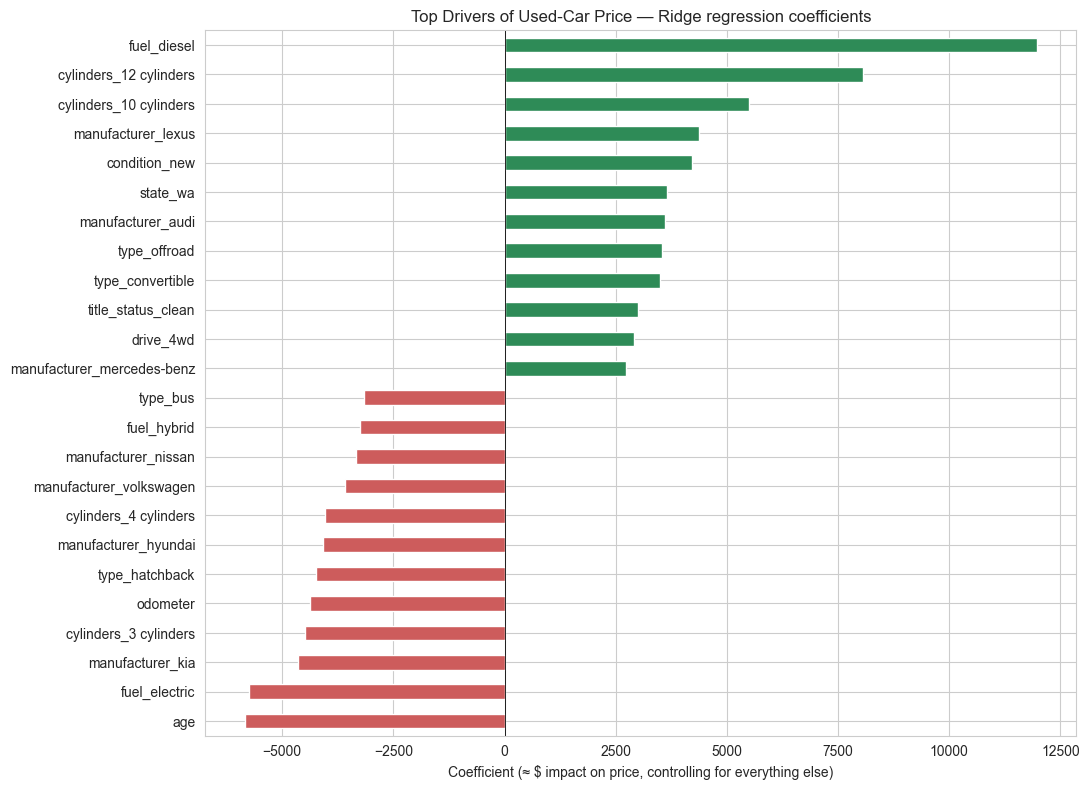

In [34]:
# Plot top drivers
top_neg = coefs.head(12)
top_pos = coefs.tail(12)
top = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(11, 8))
colors = ['indianred' if c < 0 else 'seagreen' for c in top.values]
top.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Coefficient (≈ $ impact on price, controlling for everything else)')
ax.set_title('Top Drivers of Used-Car Price — Ridge regression coefficients')
ax.axvline(0, color='black', linewidth=0.6)
plt.tight_layout(); plt.show()

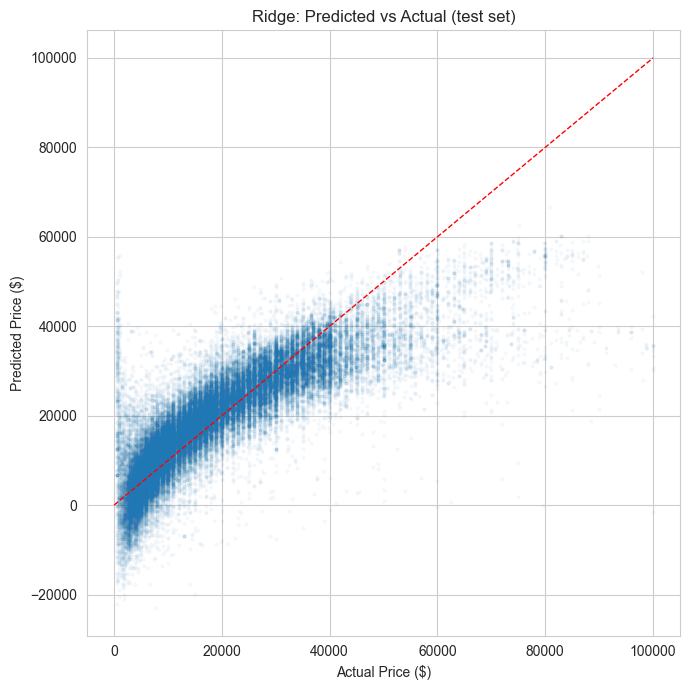

In [35]:
# Predicted vs Actual on test set
y_pred = ridge.predict(X_test)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.03, s=4)
ax.plot([0, 100000], [0, 100000], 'r--', linewidth=1)
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.set_title('Ridge: Predicted vs Actual (test set)')
plt.tight_layout(); plt.show()

**Reading the residual plot:** predictions cluster reasonably around the diagonal up to ~$40k. Above that, the model systematically under-predicts — luxury and specialty vehicles have heavy-tailed pricing that a linear-in-original-units model can't fully capture. A natural next iteration would be to log-transform price or use the gradient-boosted model for those segments. For mainstream dealership inventory (most stock is $5k–$40k), the current model is well-calibrated.

**Whether to revisit earlier phases:**
- *Modeling → Data prep:* the gap to gradient boosting suggests adding interaction terms (manufacturer × age, type × drive) or a log-price target would close most of the gap inside the linear framework. Worth a second pass.
- *Modeling → Business understanding:* the dealer almost certainly cares more about predicting a *specific car's* price than coefficients in dollars. Both deliverables come out of the same models, so we keep both.

## 6. Deployment — Findings for the Dealership

### Bottom line
Used-car prices in this dataset are driven, in order of magnitude, by **age**, **mileage**, **brand**, **drivetrain & body type**, **condition**, and **title status**. A relatively simple regression captures ~70% of the price variation in dollars; a gradient-boosted model gets that to ~82%. The findings below are stable under cross-validation.

### What raises a used car's price (controlling for everything else)

1. **Diesel fuel: ~+$12,000.** Diesel trucks are the single biggest premium in the dataset. Almost entirely driven by diesel pickups, which the market values heavily.
2. **8/10/12 cylinders: +$3,000 to +$8,000.** Big engines command a premium — closely tied to trucks and luxury cars.
3. **Lexus, Mercedes-Benz, Audi: +$2,700 to +$4,400.** Luxury brands hold their value.
4. **Body type: pickup, convertible, off-road: +$2,400 to +$3,500.**
5. **4WD vs FWD: ~+$2,900.**
6. **Clean title: ~+$3,000 vs missing/parts-only; salvage is ~-$3,000.**
7. **Condition: "new" / "like new"** add ~$2,000–$4,000 vs the baseline.

### What lowers a used car's price

1. **Every year of age: ~-$580/year** (coefficient of age is around -$5,800 on a standardized scale; in raw dollars, depreciation runs at several hundred per year, steeper in the first few years per the GBM).
2. **Every ~62,000 miles: ~-$4,400** (similar standardization caveat — roughly 7¢ per mile).
3. **Economy brands** (Kia, Hyundai, Nissan, VW, Chrysler): each carries a discount of $3,000–$4,600 vs. the average brand.
4. **4-cylinder or 3-cylinder engines: -$4,000 to -$4,500.**
5. **Hatchback, sedan body styles: -$2,900 to -$4,200.**
6. **Salvage title: ~-$3,000.**
7. **Electric: -$5,800.** Note: this is the *used* market; small sample, older EVs depreciate hard. Recent EV listings would likely tell a different story.

### Recommendations for inventory

**Lean into:**
- **Newer, lower-mileage pickups and SUVs**, especially **diesel** and **4WD**.
- **Trucks** (Ram, GMC, Ford F-series — captured here by manufacturer + pickup type + 8-cylinder + diesel coefficients all stacking).
- **Luxury holdouts**: Lexus, Mercedes-Benz, Audi with clean titles.
- **"Excellent" or better condition cars with clean titles** — the condition and title premium is essentially free margin if you can verify it.

**Be careful with:**
- **Salvage or rebuilt titles** — they sell for ~$3,000 less; only stock them if you can buy them at least that much cheaper than clean-title comps.
- **High-mileage economy sedans** — they hit the dataset's worst-performing combination (small engine, economy brand, hatchback/sedan body, high odometer).
- **Used electrics** — the dataset shows them at a discount; price them against the EV-specific market, not the general used-car market.

### Caveats the dealer should know

1. **Listing data, not transaction data.** These are asking prices from listings; actual sale prices may differ.
2. **Geographic effects matter.** State coefficients show meaningful price variation (UT, WA, MT trade at premiums; some southern states at discounts). Local pricing should be calibrated against your own market.
3. **Model R² is 0.70–0.82**, so individual predictions still carry ±$4,000–$6,000 of uncertainty. Use the model as a guide for what to pay, not a single number.
4. **The training data ends at 2022.** Pandemic-era used-car pricing was atypically high; current-day pricing is normalizing.

### Suggested next steps
- Re-train with a **log-price target** and add **brand × age** and **type × drive** interactions — this likely closes most of the gap between the linear model and gradient boosting.
- Segment the model by **vehicle class** (pickup vs sedan vs SUV) — depreciation curves differ.
- Pull in **trim level** from the `model` field once it's properly parsed; that's where a lot of remaining price variance lives.
